#   Analisis de las matrices de confusión

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Rutas de los archivos

paths = {
    "Modelo Arbol de Decision": "DecisionTree_confusion_matrix_5000.csv",
    "Modelo Naive Bayes": "NaiveBayes-confusion_matrix_complete.csv",
    "Modelo TF-IDF Reg Log": "TF-IDF-REGLOG-confusion_matrix_complete.csv",
}


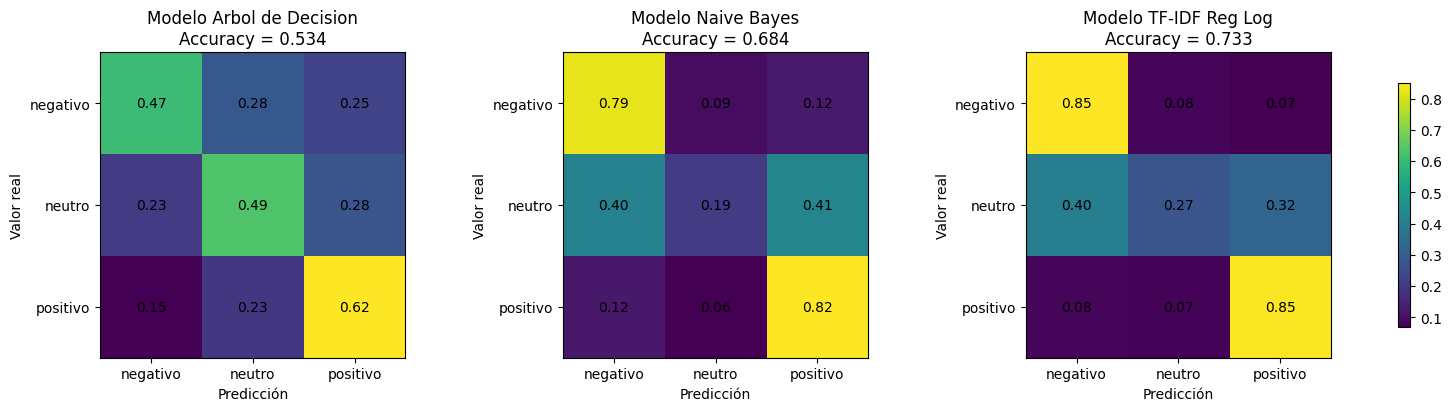

In [7]:
# =========================
# Crear figura con subplots horizontales
# =========================
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(paths),
    figsize=(15, 4),
    constrained_layout=True
)

# =========================
# Loop para cada modelo
# =========================
for ax, (name, path) in zip(axes, paths.items()):

    df = pd.read_csv(path)
    labels = df.iloc[:, 0].values
    cm = df.iloc[:, 1:].values

    # Normalización por filas
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    # Accuracy
    accuracy = np.trace(cm) / np.sum(cm)

    im = ax.imshow(cm_norm)
    ax.set_title(f"{name}\nAccuracy = {accuracy:.3f}")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    # Valores dentro de cada celda
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            ax.text(
                j, i,
                f"{cm_norm[i, j]:.2f}",
                ha="center",
                va="center"
            )

# =========================
# Barra de color compartida
# =========================
fig.colorbar(im, ax=axes, shrink=0.8)

plt.show()

## 1.- Análisis de resultados



En este trabajo se realizó una comparación entre distintos modelos de clasificación aplicados a un problema de análisis de sentimiento, específicamente **TF-IDF con Regresión Logística**, **Naive Bayes** y **Decision Tree**, utilizando como principal herramienta de evaluación las matrices de confusión obtenidas a partir de los datos de prueba.

### 1.1.- Modelo TF-IDF con Regresión Logística

El análisis visual de las matrices de confusión permitió identificar diferencias claras en el comportamiento de los modelos. El modelo basado en **TF-IDF con Regresión** Logística presentó una mayor concentración de predicciones correctas en la diagonal principal, lo que indica un mejor desempeño global y una adecuada capacidad de generalización. Asimismo, este modelo mostró un equilibrio más consistente entre las distintas clases, reduciendo la confusión entre categorías semánticamente cercanas.

### 1.2.- Modelo Naive Bayes

El modelo **Naive Bayes** obtuvo resultados competitivos en las clases mayoritarias; sin embargo, evidenció una mayor confusión en la clase neutra, lo cual puede atribuirse a la fuerte suposición de independencia condicional entre las características, inherente a este enfoque probabilístico. Aunque eficiente y computacionalmente ligero, esta limitación afecta su desempeño en escenarios donde las relaciones semánticas entre palabras son relevantes.

### 1.3.- Modelo Arbol de Desición

El modelo **Arbol de Decisión** mostró un rendimiento inferior en comparación con los otros enfoques, presentando una mayor dispersión de errores y menor estabilidad. Este comportamiento sugiere una limitada capacidad de generalización para problemas de clasificación de texto de alta dimensionalidad cuando se utiliza de forma individual.

## 1.4.- Comparación conceptual

| Modelo          | Generalización | Estabilidad | Manejo de texto |
| --------------- | -------------- | ----------- | --------------- |
| TF-IDF + RegLog | ⭐⭐⭐⭐☆          | ⭐⭐⭐⭐☆       | ⭐⭐⭐⭐☆           |
| Naive Bayes     | ⭐⭐⭐☆☆          | ⭐⭐⭐☆☆       | ⭐⭐⭐☆☆           |
| Decision Tree   | ⭐⭐☆☆☆          | ⭐⭐☆☆☆       | ⭐⭐☆☆☆           |


### 1.5.- Conclusión

Considerando tanto el análisis empírico a través de las matrices de confusión como los fundamentos teóricos de cada algoritmo, se recomienda el uso del modelo **TF-IDF con Regresión Logística** como la alternativa más adecuada para el problema abordado, al ofrecer un mejor balance entre precisión, estabilidad y capacidad de generalización.